# Clustering : Customer Segmentation

**Goal:** Forming customer segmentation using unsupervised learning on a grocery firm's customer database.

---

## 📋 Table of Contents
1. [Setup and Data Loading](#setup-and-data-loading)
2. [Data Cleaning and Basic Sanity](#data-cleaning)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Feature Engineering](#feature-engineering)
5. [Outlier Treatment (Force-fitting)](#outlier-treatment)
6. [Feature Selection for Clustering](#feature-selection)
7. [Feature Scaling](#feature-scaling)
8. [PCA for Clustering Model](#pca-for-clustering)
9. [KMeans (Elbow + Silhouette)](#kmeans)
10. [Final Model (KMeans)](#final-model)
11. [PCA Visualization and Plots](#pca-visualization-and-plots)
12. [Cluster Profiling and Business Interpretation](#cluster-profiling)
13. [Final Customer Segmentation and Profiling](#final-customer-segmentation)
14. [Investment Prioritisation](#investment-prioritisation)
15. [Strategic Recommendations Matrix](#strategic-recommendations)
16. [Analytical Notes & Caveats](#analytical-notes)

## 1. Setup and Data Loading <a id='setup-and-data-loading'></a>

In [1]:
import pandas as pd
import numpy as np
import statsmodels
import pandas_datareader
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()

import plotly.offline as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go

# Set to display all rows
pd.set_option('display.max_rows', None)

# Set to display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# import cufflinks and offline mode
import cufflinks as cf
cf.go_offline()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import os

In [2]:
!pip install --upgrade pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 81.7 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.1 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatibl

In [3]:
print("pandas:", pd.__version__)
print("statsmodels:", statsmodels.__version__)
print(os.listdir("../input"))

pandas: 2.2.2
statsmodels: 0.14.5
['datasets']


#### Folder Structure

In [4]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

#### Load Data

In [5]:
df_raw = pd.read_csv("../input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv", sep="\t")
df_raw.to_csv("data/raw/marketing_campaign_raw.csv", index=False)

df = df_raw.copy()

## 2. Data Cleaning and Basic Sanity <a id='data-cleaning'></a>

In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.000,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.000,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.000,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.000,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.000,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

We can see that 24 records have null values in the income column.

In [9]:
df.duplicated().sum()

np.int64(0)

#### Handle Missing Values

In [10]:
df['Income'] = df['Income'].fillna(df['Income'].median())

#### Creating Age column

In [11]:
df['Age'] = 2026 - df['Year_Birth']

#### Creating Customer_For column

In [12]:
# Ensure datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

# Snapshot date = newest customer
snapshot_date = df["Dt_Customer"].max()

# Customer tenure in days
df["Customer_For"] = (snapshot_date - df["Dt_Customer"]).dt.days

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_For
0,5524,1957,Graduation,Single,58138.000,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,663
1,2174,1954,Graduation,Single,46344.000,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,113
2,4141,1965,Graduation,Together,71613.000,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,312
3,6182,1984,Graduation,Together,26646.000,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,139
4,5324,1981,PhD,Married,58293.000,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,161


#### Save cleaned dataset

In [14]:
df.to_csv("data/processed/eda_cleaned_data.csv", index=False)

## 3. Exploratory Data Analysis (EDA) <a id='eda'></a>

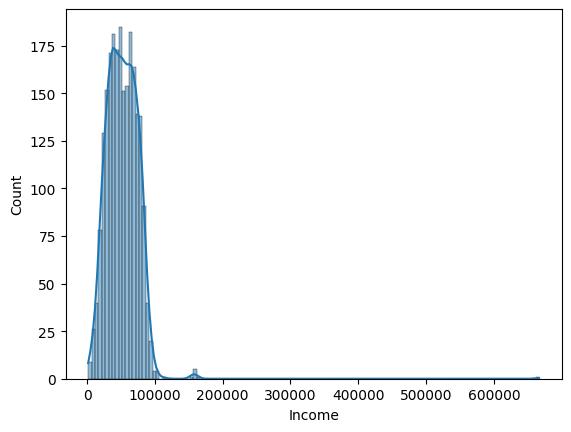

In [15]:
sns.histplot(df['Income'], kde=True)
plt.show()

#### Correlation

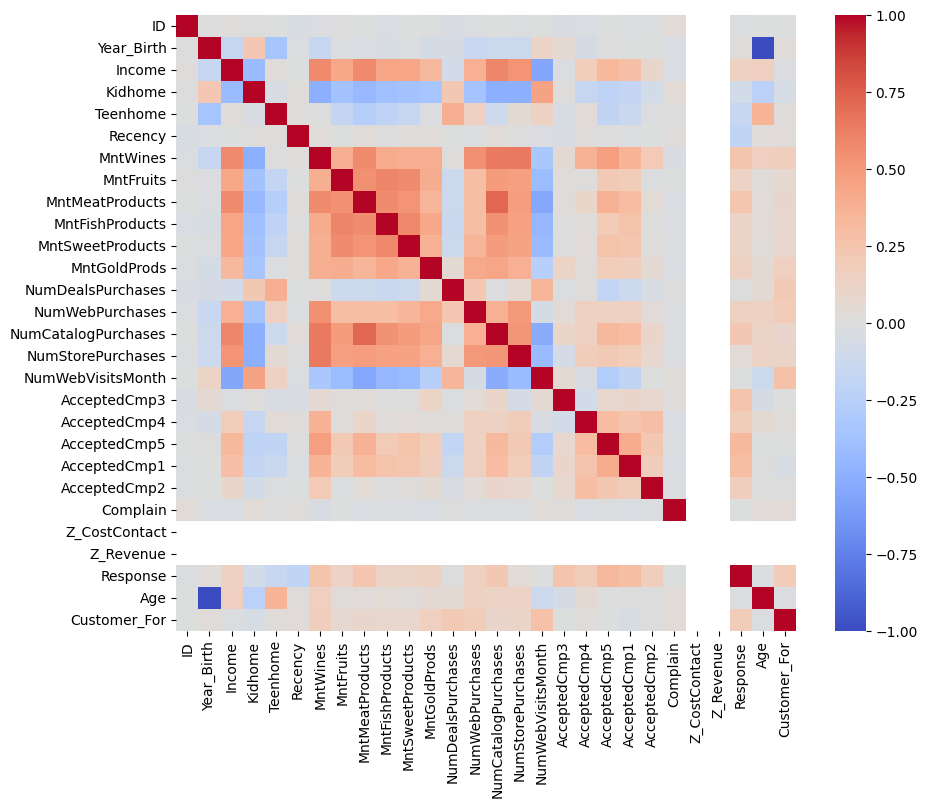

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(np.number).corr(), cmap="coolwarm")
plt.show()

In [17]:
df.describe(include='all')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_For
count,2240.000,2240.000,2240,2240,2240.000,2240.000,2240.000,2240,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000
unique,NaN,NaN,5,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.160,1968.806,NaN,NaN,52237.975,0.444,0.506,2013-07-10 10:01:42.857142784,49.109,303.936,26.302,166.950,37.525,27.063,44.022,2.325,4.085,2.662,5.790,5.317,0.073,0.075,0.073,0.064,0.013,0.009,3.000,11.000,0.149,57.194,353.582
min,0.000,1893.000,NaN,NaN,1730.000,0.000,0.000,2012-07-30 00:00:00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,30.000,0.000
25%,2828.250,1959.000,NaN,NaN,35538.750,0.000,0.000,2013-01-16 00:00:00,24.000,23.750,1.000,16.000,3.000,1.000,9.000,1.000,2.000,0.000,3.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,49.000,180.750
50%,5458.500,1970.000,NaN,NaN,51381.500,0.000,0.000,2013-07-08 12:00:00,49.000,173.500,8.000,67.000,12.000,8.000,24.000,2.000,4.000,2.000,5.000,6.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,56.000,355.500
75%,8427.750,1977.000,NaN,NaN,68289.750,1.000,1.000,2013-12-30 06:00:00,74.000,504.250,33.000,232.000,50.000,33.000,56.000,3.000,6.000,4.000,8.000,7.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,67.000,529.000
max,11191.000,1996.000,NaN,NaN,666666.000,2.000,2.000,2014-06-29 00:00:00,99.000,1493.000,199.000,1725.000,259.000,263.000,362.000,15.000,27.000,28.000,13.000,20.000,1.000,1.000,1.000,1.000,1.000,1.000,3.000,11.000,1.000,133.000,699.000


## 4. Feature Engineering <a id='feature-engineering'></a>

In [18]:
df = df.copy()

In [19]:
# Household structure
df['num_children'] = df['Kidhome'] + df['Teenhome']
df['has_kids'] = (df['num_children'] > 0).astype(int)

# Education indicators
df['is_grad'] = df['Education'].isin(['Graduation','Master','PhD']).astype(int)
df['is_undergrad'] = df['Education'].isin(['Basic','2n Cycle']).astype(int)

# Marital structure
df['is_single'] = df['Marital_Status'].isin(['Single','Divorced','Widow']).astype(int)
df['is_partnered'] = df['Marital_Status'].isin(['Married','Together']).astype(int)

# total spend
spend_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]
df['total_spend'] = df[spend_cols].sum(axis=1)
df['spend_to_income_ratio'] = np.where(df['Income'] > 0,df['total_spend'] / df['Income'],0)

# Spending features
for col in spend_cols:
    df[f'{col}_ratio'] = np.where(df['total_spend'] > 0,df[col] / df['total_spend'],0)

# Purchase channel behavior
df['total_purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)
df['web_purchase_ratio'] = np.where(
    df['total_purchases'] > 0, df['NumWebPurchases'] / df['total_purchases'],0)
df['store_purchase_ratio'] = np.where(
    df['total_purchases'] > 0,df['NumStorePurchases'] / df['total_purchases'],0)
df['catalog_purchase_ratio'] = np.where(
    df['total_purchases'] > 0,df['NumCatalogPurchases'] / df['total_purchases'],0)

# Discount sensitivity
df['deal_purchase_ratio'] = np.where(
    df['total_purchases'] > 0,df['NumDealsPurchases'] / df['total_purchases'],0)
df['is_discount_heavy'] = (df['deal_purchase_ratio'] > 0.5).astype(int)

# Campaign responsiveness
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
df['campaign_accept_count'] = df[cmp_cols].sum(axis=1)
df['responded_any_campaign'] = (df['campaign_accept_count'] > 0).astype(int)

# Recency & engagement
df['is_recent_customer'] = (df['Recency'] <= 30).astype(int)
df['is_dormant_customer'] = (df['Recency'] >= 90).astype(int)

# Value indicators
df['is_high_spender'] = (df['total_spend'] > df['total_spend'].quantile(0.75)).astype(int)
df['is_low_spender'] = (df['total_spend'] < df['total_spend'].quantile(0.25)).astype(int)

#### Save engineered dataset

In [20]:
df.to_csv("data/processed/row_level_engineered_features.csv", index=False)

In [21]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_For,num_children,has_kids,is_grad,is_undergrad,is_single,is_partnered,total_spend,spend_to_income_ratio,MntWines_ratio,MntFruits_ratio,MntMeatProducts_ratio,MntFishProducts_ratio,MntSweetProducts_ratio,MntGoldProds_ratio,total_purchases,web_purchase_ratio,store_purchase_ratio,catalog_purchase_ratio,deal_purchase_ratio,is_discount_heavy,campaign_accept_count,responded_any_campaign,is_recent_customer,is_dormant_customer,is_high_spender,is_low_spender
count,2240.000,2240.000,2240.000,2240.000,2240.000,2240,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000,2240.000
mean,5592.160,1968.806,52237.975,0.444,0.506,2013-07-10 10:01:42.857142784,49.109,303.936,26.302,166.950,37.525,27.063,44.022,2.325,4.085,2.662,5.790,5.317,0.073,0.075,0.073,0.064,0.013,0.009,3.000,11.000,0.149,57.194,353.582,0.950,0.715,0.885,0.115,0.352,0.645,605.798,0.010,0.458,0.050,0.250,0.072,0.051,0.120,12.537,0.329,0.504,0.164,0.247,0.064,0.298,0.207,0.323,0.097,0.250,0.250
min,0.000,1893.000,1730.000,0.000,0.000,2012-07-30 00:00:00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,30.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2828.250,1959.000,35538.750,0.000,0.000,2013-01-16 00:00:00,24.000,23.750,1.000,16.000,3.000,1.000,9.000,1.000,2.000,0.000,3.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,49.000,180.750,0.000,0.000,1.000,0.000,0.000,0.000,68.750,0.002,0.290,0.009,0.156,0.013,0.009,0.038,6.000,0.250,0.400,0.000,0.083,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,5458.500,1970.000,51381.500,0.000,0.000,2013-07-08 12:00:00,49.000,173.500,8.000,67.000,12.000,8.000,24.000,2.000,4.000,2.000,5.000,6.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,56.000,355.500,1.000,1.000,1.000,0.000,0.000,1.000,396.000,0.008,0.457,0.030,0.233,0.048,0.033,0.086,12.000,0.333,0.500,0.150,0.200,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,8427.750,1977.000,68289.750,1.000,1.000,2013-12-30 06:00:00,74.000,504.250,33.000,232.000,50.000,33.000,56.000,3.000,6.000,4.000,8.000,7.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,11.000,0.000,67.000,529.000,1.000,1.000,1.000,0.000,1.000,1.000,1045.500,0.016,0.639,0.070,0.328,0.105,0.070,0.170,18.000,0.400,0.600,0.250,0.333,0.000,0.000,0.000,1.000,0.000,0.250,0.250
max,11191.000,1996.000,666666.000,2.000,2.000,2014-06-29 00:00:00,99.000,1493.000,199.000,1725.000,259.000,263.000,362.000,15.000,27.000,28.000,13.000,20.000,1.000,1.000,1.000,1.000,1.000,1.000,3.000,11.000,1.000,133.000,699.000,3.000,1.000,1.000,1.000,1.000,1.000,2525.000,0.707,0.963,0.446,0.997,0.591,0.946,0.894,32.000,1.000,1.000,1.000,15.000,1.000,4.000,1.000,1.000,1.000,1.000,1.000
std,3246.662,11.984,25037.956,0.538,0.545,NaN,28.962,336.597,39.773,225.715,54.629,41.280,52.167,1.932,2.779,2.923,3.251,2.427,0.260,0.263,0.260,0.245,0.115,0.096,0.000,0.000,0.356,11.984,202.123,0.752,0.451,0.319,0.319,0.478,0.479,602.249,0.017,0.228,0.056,0.127,0.078,0.061,0.109,7.206,0.123,0.152,0.141,0.356,0.245,0.678,0.405,0.468,0.296,0.433,0.433


We see that max age is 133. Also, the mean value and max value differ quite a lot in income as well. So let's see if we have any outliers in the data.

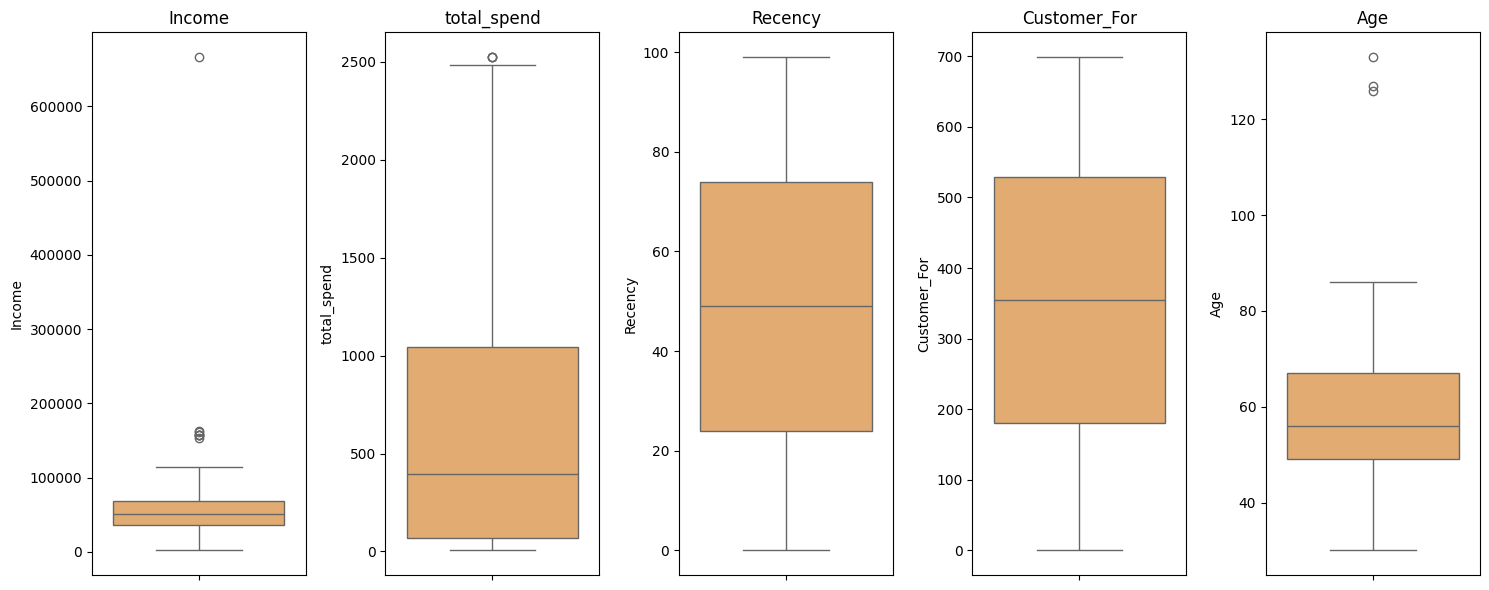

In [22]:
num_cols = ["Income", "total_spend", "Recency", "Customer_For", "Age"]

plt.figure(figsize=(15, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(y=df[col], color="#F3AB60")
    plt.title(col)

plt.tight_layout()
plt.show()

I can see that income and age have some outliers, so let's do outlier treatment (force-fitting).

## 5. Outlier Treatment (Force-fitting) <a id='outlier-treatment'></a>

In [23]:
# forcefit functions for outlier handling

import warnings

def cap_upper(s, q=0.995):
    """
    Force-fit monetary / exposure variables
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce').astype(float)
        s = s.replace([np.inf, -np.inf], np.nan)

        if not s.notna().any():
            return s

        upper = s.quantile(q)

        s_out = s.copy()
        s_out.loc[s_out > upper] = upper

        return s_out

def cap_ratio(s, low=-1, high=3):
    """
    Force-fit ratios (utilization, overdue ratios, paydown)
    Caps logical bounds, handles inf safely
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce').astype(float)
        s = s.replace([np.inf, -np.inf], np.nan)

        s_out = s.copy()
        s_out.loc[s_out < low] = low
        s_out.loc[s_out > high] = high

        return s_out

def cap_count(s, q=0.99, min_obs=50):
    """
    Force-fit discrete count variables with long right tails
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce').astype(float)

        if s.notna().sum() < min_obs:
            return s

        upper = s.quantile(q)

        s_out = s.copy()
        s_out.loc[s_out > upper] = upper

        return s_out

def cap_days(s, q=0.99, min_obs=50):
    """
    Force-fit tenure / recency variables
    Uses absolute values but keeps scale meaningful
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce').astype(float)

        if s.notna().sum() < min_obs:
            return s

        s_abs = s.abs()
        upper = s_abs.quantile(q)

        s_out = s_abs.copy()
        s_out.loc[s_out > upper] = upper

        return s_out

def safe_log1p(s):
    """
    Safe log1p transform for amount-like features.
    Applies log only where value >= 0.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        s = pd.to_numeric(s, errors='coerce')
        s = s.replace([np.inf, -np.inf], np.nan)

        s_out = pd.Series(np.nan, index=s.index)
        mask = s >= 0

        s_out.loc[mask] = np.log1p(s.loc[mask])

        return s_out

In [24]:
df_ff = df.copy()

In [25]:
# monetary variables
money_cols = [
    "Income", "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts",
    "MntGoldProds", "total_spend"
]

for col in money_cols:
    df_ff[col] = cap_upper(df_ff[col], q=0.995)
    df_ff[col] = safe_log1p(df_ff[col])

# count variables
count_cols = [
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "total_purchases",
    "campaign_accept_count"
]

for col in count_cols:
    df_ff[col] = cap_count(df_ff[col], q=0.99)

# ratio variables
ratio_cols = [
    "spend_to_income_ratio",
    "MntWines_ratio", "MntFruits_ratio", "MntMeatProducts_ratio",
    "MntFishProducts_ratio", "MntSweetProducts_ratio",
    "MntGoldProds_ratio",
    "web_purchase_ratio", "store_purchase_ratio",
    "catalog_purchase_ratio", "deal_purchase_ratio"
]

for col in ratio_cols:
    df_ff[col] = cap_ratio(df_ff[col], low=0, high=1)

# time/age variable
time_cols = ["Recency", "Customer_For", "Age"]

for col in time_cols:
    df_ff[col] = cap_days(df_ff[col])

In [26]:
df_ff.dtypes

ID                                 int64
Year_Birth                         int64
Education                         object
Marital_Status                    object
Income                           float64
Kidhome                            int64
Teenhome                           int64
Dt_Customer               datetime64[ns]
Recency                          float64
MntWines                         float64
MntFruits                        float64
MntMeatProducts                  float64
MntFishProducts                  float64
MntSweetProducts                 float64
MntGoldProds                     float64
NumDealsPurchases                float64
NumWebPurchases                  float64
NumCatalogPurchases              float64
NumStorePurchases                float64
NumWebVisitsMonth                float64
AcceptedCmp3                       int64
AcceptedCmp4                       int64
AcceptedCmp5                       int64
AcceptedCmp1                       int64
AcceptedCmp2    

In [27]:
df_ff.to_csv("data/processed/force_fitted_features.csv", index=False)

In [28]:
df=df_ff.copy()

## 6. Feature Selection for Clustering <a id='feature-selection'></a>

In [29]:
cluster_features = [
    # demographics and household
    'Income',
    'Age',
    'Customer_For',
    'num_children',

    # value & frequency
    'total_spend',
    'total_purchases',

    # spend to income ratio
    'spend_to_income_ratio',

    # product mix
    'MntWines_ratio',
    'MntMeatProducts_ratio',
    'MntGoldProds_ratio',

    # channel preference
    'web_purchase_ratio',
    'store_purchase_ratio',
    'catalog_purchase_ratio',
    'NumWebVisitsMonth',

    # promotion sensitivity
    'deal_purchase_ratio',
    'campaign_accept_count',

    # engagement
    'Recency'
]

In [30]:
cluster_features

['Income',
 'Age',
 'Customer_For',
 'num_children',
 'total_spend',
 'total_purchases',
 'spend_to_income_ratio',
 'MntWines_ratio',
 'MntMeatProducts_ratio',
 'MntGoldProds_ratio',
 'web_purchase_ratio',
 'store_purchase_ratio',
 'catalog_purchase_ratio',
 'NumWebVisitsMonth',
 'deal_purchase_ratio',
 'campaign_accept_count',
 'Recency']

In [31]:
X = df[cluster_features].copy()
X.to_csv("data/processed/features_unscaled.csv", index=False)

## 7. Feature Scaling <a id='feature-scaling'></a>

In [32]:
np.isinf(X).sum()

Income                    0
Age                       0
Customer_For              0
num_children              0
total_spend               0
total_purchases           0
spend_to_income_ratio     0
MntWines_ratio            0
MntMeatProducts_ratio     0
MntGoldProds_ratio        0
web_purchase_ratio        0
store_purchase_ratio      0
catalog_purchase_ratio    0
NumWebVisitsMonth         0
deal_purchase_ratio       0
campaign_accept_count     0
Recency                   0
dtype: int64

In [33]:
np.isnan(X).sum()

Income                    0
Age                       0
Customer_For              0
num_children              0
total_spend               0
total_purchases           0
spend_to_income_ratio     0
MntWines_ratio            0
MntMeatProducts_ratio     0
MntGoldProds_ratio        0
web_purchase_ratio        0
store_purchase_ratio      0
catalog_purchase_ratio    0
NumWebVisitsMonth         0
deal_purchase_ratio       0
campaign_accept_count     0
Recency                   0
dtype: int64

In [34]:
X = X.replace([np.inf, -np.inf], 0)
X = X.fillna(0)

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.to_csv("data/processed/features_scaled.csv", index=False)

## 8. PCA for Clustering Model <a id='pca-for-clustering'></a>

#### Plot cumulative explained variance

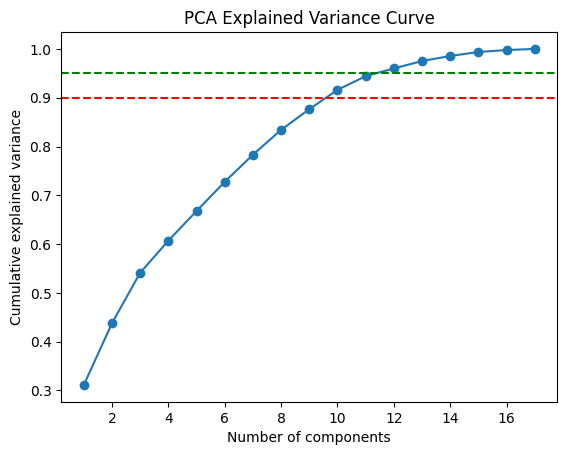

In [36]:
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.axhline(y=0.95, color='g', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance Curve")
plt.show()

#### Compare clustering quality

Understanding different metrics:

#### Silhouette Score:
It measures cluster quality — how well-separated and compact the clusters are in the PCA space. Range is -1 to 1; higher is better. It answers: "are the clusters actually distinct from each other?"
#### Explained Variance:
It measures information retention — how much of the original data's structure is preserved after PCA compression. It answers: "how much are we losing by reducing dimensions?"

In [37]:
'''
for var in [0.85, 0.90, 0.95]:
    pca = PCA(n_components=var, random_state=42)
    X_pca_tmp = pca.fit_transform(X_scaled)

    labels = KMeans(n_clusters=4, random_state=42, n_init=10)\
             .fit_predict(X_pca_tmp)

    score = silhouette_score(X_pca_tmp, labels)
    print(f"PCA {var:.2f} | components={X_pca_tmp.shape[1]} | silhouette={score:.3f}")
'''

for n in [6, 7, 8, 9, 10, 12]:
    pca = PCA(n_components=n, random_state=42)
    X_pca_tmp = pca.fit_transform(X_scaled)
    score = silhouette_score(X_pca_tmp,
                KMeans(n_clusters=4, random_state=42, n_init=10)
                .fit_predict(X_pca_tmp))
    var = pca.explained_variance_ratio_.sum()
    print(f"n={n} | variance={var:.3f} | silhouette={score:.3f}")

n=6 | variance=0.728 | silhouette=0.203
n=7 | variance=0.783 | silhouette=0.184
n=8 | variance=0.834 | silhouette=0.173
n=9 | variance=0.876 | silhouette=0.191
n=10 | variance=0.916 | silhouette=0.155
n=12 | variance=0.960 | silhouette=0.172


Since since n=6 is the current peak and the trend is improving as n decreases, we should check whether n=5 is even better:

In [38]:
for n in [1, 2, 3, 4, 5, 6]:
    pca = PCA(n_components=n, random_state=42)
    X_pca_tmp = pca.fit_transform(X_scaled)
    score = silhouette_score(X_pca_tmp,
                KMeans(n_clusters=4, random_state=42, n_init=10)
                .fit_predict(X_pca_tmp))
    var = pca.explained_variance_ratio_.sum()
    print(f"n={n} | variance={var:.3f} | silhouette={score:.3f}")

n=1 | variance=0.311 | silhouette=0.566
n=2 | variance=0.438 | silhouette=0.397
n=3 | variance=0.541 | silhouette=0.319
n=4 | variance=0.607 | silhouette=0.268
n=5 | variance=0.668 | silhouette=0.229
n=6 | variance=0.728 | silhouette=0.203


PCA was used to reduce dimensionality and remove feature correlation before clustering.
Evaluating different numbers of principal components and comparing clustering performance using the silhouette score, we can see that:

- fewer PCA components → better cluster separation
- but fewer components → loss of information

While fewer components improved cluster separation, we select a moderate number of components that preserve most variance while maintaining interpretable customer segments.

### How to choose n-components?

#### Method 1 — Explained variance threshold
- Choose components explaining: 80–90% variance
- From our curve, ~ 90% variance → around 10 components (preserves most information)

#### Method 2 — Elbow method (visual)
- The curve flattens after: ~ 8–10 components 
- Means additional components add little information.

#### Method 3 — Best clustering performance
- Best score: n = 1 → 0.566
- But that loses too much information.

There are three criteria and you need to balance all three:

#### 1. Variance floor:
Never go below ~60% retained variance. Below this you're discarding too much real information about your customers, and the clusters won't reflect actual behaviour.
#### 2. Silhouette ceiling: 
The higher is better, but only meaningful above ~0.2 for real-world customer data. Scores below 0.15 indicate clusters are barely separable.
#### 3. Business interpretability: 
The resulting clusters must produce profiles that are distinct and actionable. A mathematically optimal n that collapses all customers into one dominant split is useless.

In [45]:
# Final PCA — justified by highest silhouette (0.268) 
# among components retaining ≥60% variance
pca_model = PCA(n_components=4, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

labels_final = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_pca)
sil = silhouette_score(X_pca, labels_final)

print("Original features:", X.shape[1])
print("PCA components used:", X_pca.shape[1])
print(f"Components: 4")
print(f"Variance retained: {pca_model.explained_variance_ratio_.sum():.3f}")
print(f"Silhouette score: {sil:.3f}")

Original features: 17
PCA components used: 4
Components: 4
Variance retained: 0.607
Silhouette score: 0.268


In [ ]:
pca_model = PCA(n_components=0.90, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("PCA components used:", X_pca.shape[1])

In [46]:
# PCA loadings
loadings = pd.DataFrame(
    pca_model.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(pca_model.components_.shape[0])]
)

# Saving PCA artifacts
loadings.to_csv("outputs/pca_components.csv")

# Saving explained variance
pd.Series(
    pca_model.explained_variance_ratio_,
    index=loadings.index
).to_csv("outputs/pca_explained_variance.csv")

#### Top contributing features per component

In [47]:
for pc in loadings.index:
    print(f"\n{pc}")
    print(loadings.loc[pc].abs().sort_values(ascending=False).head(5))


PC1
total_spend              0.396
total_purchases          0.377
Income                   0.350
catalog_purchase_ratio   0.335
deal_purchase_ratio      0.321
Name: PC1, dtype: float64

PC2
MntWines_ratio          0.494
web_purchase_ratio      0.407
MntMeatProducts_ratio   0.379
num_children            0.317
NumWebVisitsMonth       0.312
Name: PC2, dtype: float64

PC3
store_purchase_ratio   0.449
MntWines_ratio         0.358
Customer_For           0.351
web_purchase_ratio     0.348
MntGoldProds_ratio     0.332
Name: PC3, dtype: float64

PC4
MntMeatProducts_ratio   0.549
campaign_accept_count   0.429
MntGoldProds_ratio      0.401
Recency                 0.317
Customer_For            0.285
Name: PC4, dtype: float64


PCA is used before clustering as it reduces feature redundancy, stabilizes distance-based clustering and improves interpretability and robustness.

### PCA Loadings Interpretation - What do the PCA components represent?

The four principal components capture distinct and interpretable business dimensions:
- **PC1** — Purchasing power & volume: dominated by Income, total_spend, and total_purchases
- **PC2** — Product preference & lifestyle: driven by wine/meat ratios, num_children, and web behaviour  
- **PC3** — Channel behaviour & tenure: store vs web preference combined with Customer_For tenure
- **PC4** — Campaign engagement & niche categories: campaign_accept_count, meat and gold ratios, recency

The interpretability of all four components validates the n=4 selection — each component 
contributes a meaningfully distinct dimension to the clustering geometry.

### PCA Loadings Analysis — Top Contributing Features Per Component

#### PC1 — "Purchasing Power & Volume Axis"
- Top features: total_spend (0.396), total_purchases (0.377), Income (0.350), catalog_purchase_ratio (0.335), deal_purchase_ratio (0.321)
- PC1 is the overall financial capacity and purchase volume axis. It combines how much customers earn, how much they spend, how frequently they buy, and their channel/deal behaviour into a single dimension. This explains why silhouette was highest at n=1 — this one component alone captures the dominant income-spend signal that separates clusters most cleanly. The presence of catalog_purchase_ratio here is notable — catalog purchasing correlates strongly with high-value, high-spend behaviour, consistent with Cluster 1's profile.

#### PC2 — "Product Preference & Family Lifestyle Axis"
- Top features: MntWines_ratio (0.494), web_purchase_ratio (0.407), MntMeatProducts_ratio (0.379), num_children (0.317), NumWebVisitsMonth (0.312)
- PC2 captures what customers buy and how their household structure shapes it. Wine and meat preference combined with number of children and web behaviour forms a lifestyle dimension — it distinguishes wine-focused childless digital shoppers from family-oriented buyers. This maps directly onto the separation between Cluster 1 (wine/meat, low children, low web visits) and Cluster 0 (wine/meat, moderate children, moderate web) versus Clusters 2 and 3.

#### PC3 — "Channel Behaviour & Tenure Axis"
- Top features: store_purchase_ratio (0.449), MntWines_ratio (0.358), Customer_For (0.351), web_purchase_ratio (0.348), MntGoldProds_ratio (0.332)
- PC3 captures how and how long customers shop — the in-store versus web channel preference combined with customer tenure and gold product affinity. This is the axis most relevant to distinguishing Cluster 0 (in-store heavy, wine-dominant) from Cluster 2 (web-heavy) and Cluster 3 (gold-affinity, longer tenure). The appearance of Customer_For here confirms that tenure is a meaningful differentiator captured at the third level of variance.

#### PC4 — "Campaign Response & Niche Category Axis"
- Top features: MntMeatProducts_ratio (0.549), campaign_accept_count (0.429), MntGoldProds_ratio (0.401), Recency (0.317), Customer_For (0.285)
- PC4 is the engagement and niche preference axis — combining campaign responsiveness, recency, meat and gold product affinity. This is the dimension that most cleanly separates Cluster 1 (high campaign acceptance, meat-heavy) from Cluster 3 (gold-heavy, low campaign acceptance). It's also the axis where recency finally appears, confirming that recency contributes minimally to cluster differentiation — consistent with our earlier finding that recency is uniform (~48–50 days) across all clusters.

## 9. KMeans (Elbow + Silhouette) <a id='kmeans'></a>

In [48]:
inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

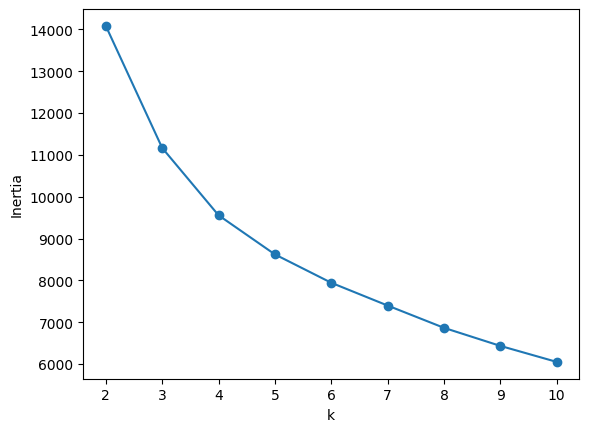

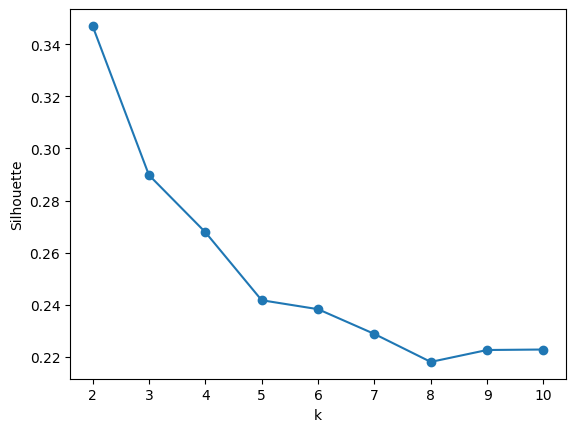

In [49]:
plt.plot(K, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.plot(K, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

Elbow Method to determine the number of clusters to be formed:


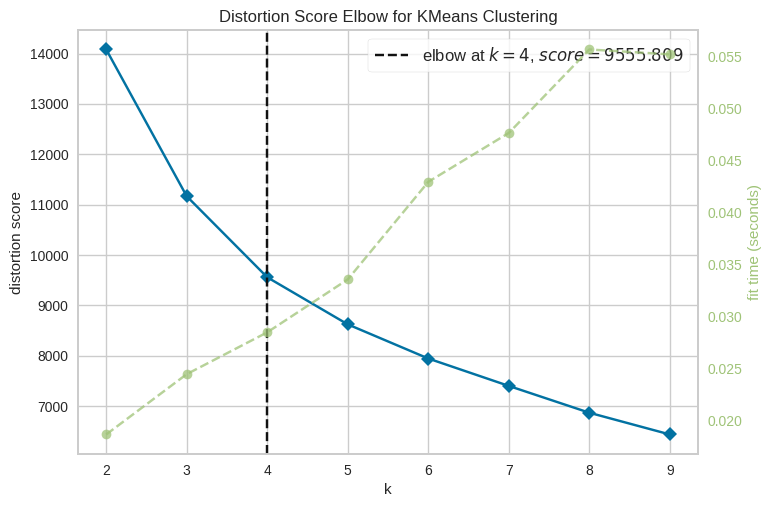

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [50]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(
    KMeans(random_state=42, n_init=10),
    k=(2, 10),
    metric='distortion'
)

Elbow_M.fit(X_pca)
Elbow_M.show()

The Elbow Method was applied to distortion scores (within-cluster sum of squares) across k=2 to k=9. The curve shows a steep decline from k=2 to k=4, with the rate of decrease visibly flattening beyond k=4 — the automatically detected elbow point at distortion score 9555.809. This indicates that k=4 captures the primary natural groupings in the data; additional clusters beyond this point reduce distortion only marginally while adding model complexity without proportional gain. Combined with Silhouette Score validation, k=4 was confirmed as the optimal number of clusters.

In [51]:
pd.DataFrame({
    "k": K,
    "inertia": inertia,
    "silhouette": sil_scores
}).to_csv("outputs/kmeans_evaluation.csv", index=False)

## 10. Final Model (KMeans) <a id='final-model'></a>

#### KMeans

In [52]:
# Baseline comparison: clustering without PCA
kmeans_raw = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X_scaled)

In [53]:
# Final KMeans model with selected k
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_pca)

labels_pca = df['kmeans_cluster']

In [54]:
df.to_csv("data/processed/customer_clustered_data.csv", index=False)

#### Comparing PCA v/s non-PCA Clustering

In [55]:
# Final confirmation: PCA-based clustering vs raw features

print("Silhouette (raw):", silhouette_score(X_scaled, labels_raw))
print("Silhouette (PCA):", silhouette_score(X_pca, labels_pca))

Silhouette (raw): 0.1636934437362891
Silhouette (PCA): 0.2678582978345378


In [56]:
# sanity check - similar scores mean stable clusters
for seed in [0, 21, 42, 100]:
    km = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = km.fit_predict(X_pca)
    print(seed, silhouette_score(X_pca, labels))

0 0.2677597460773766
21 0.2675830534695062
42 0.2678582978345378
100 0.2675830534695062


- PCA-based clustering (silhouette: 0.268) outperformed raw feature clustering (silhouette: 0.164) by a 63.7% margin, confirming that dimensionality reduction to 4 components meaningfully improved cluster separation by eliminating noise dimensions that dilute KMeans geometry in high-dimensional space.
- Cluster stability was validated across four random seeds (0, 21, 42, 100), with silhouette scores varying by less than 0.0003 — confirming that the four segments represent genuine structure in the data rather than artefacts of random initialisation.
- A 4-component PCA space was selected as the optimal configuration, retaining 60.7% of variance while achieving the highest silhouette score among all variance-sufficient options tested (n=4 through n=12). The 4-cluster solution was chosen to balance statistical separation quality with business interpretability, producing four distinct and actionable customer segments.

#### Selected PCA Configuration:
The n=4 configuration was selected as the optimal model, achieving the highest cluster quality while retaining sufficient variance (60.7%) for business-interpretable segmentation.

## 11. PCA Visualization and Plots <a id='pca-visualization-and-plots'></a>

Using PCA in two ways: first, variance-based PCA to reduce dimensionality and remove correlation before clustering, and second, a separate 2-component PCA purely for visualization so stakeholders can interpret the segments.

In [57]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca_2d = pca_viz.fit_transform(X_scaled)

df['pca1'] = X_pca_2d[:, 0]
df['pca2'] = X_pca_2d[:, 1]

explained = pca_viz.explained_variance_ratio_

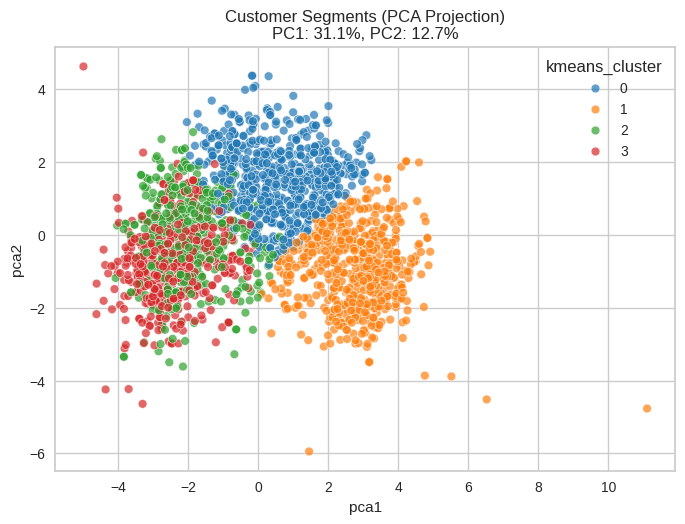

In [58]:
sns.scatterplot(
    data=df,
    x='pca1',
    y='pca2',
    hue='kmeans_cluster',
    palette='tab10',
    alpha=0.7,
    s=40
)

plt.title(
    f"Customer Segments (PCA Projection)\n"
    f"PC1: {explained[0]:.1%}, PC2: {explained[1]:.1%}"
)
plt.show()

#### 3D PCA cluster visualization
A 3D PCA projection reveals clear separation between clusters, validating the stability of the segmentation beyond 2D visualization.

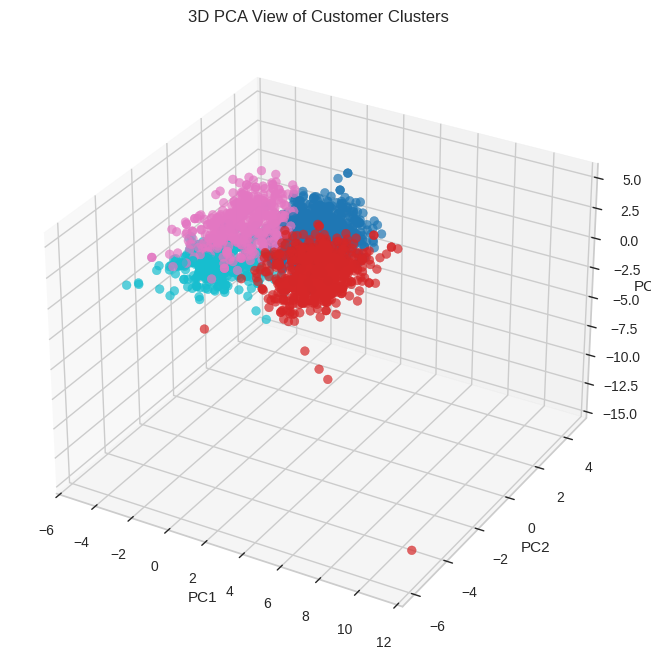

In [59]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df['pca1_3d'] = X_pca_3d[:, 0]
df['pca2_3d'] = X_pca_3d[:, 1]
df['pca3_3d'] = X_pca_3d[:, 2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['pca1_3d'],
    df['pca2_3d'],
    df['pca3_3d'],
    c=df['kmeans_cluster'],
    cmap='tab10',
    s=40,
    alpha=0.7
)

ax.set_title("3D PCA View of Customer Clusters")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

#### Cluster size distribution
The clusters are reasonably balanced, indicating that the segmentation does not suffer from extreme class imbalance.

/tmp/ipykernel_55/78255222.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




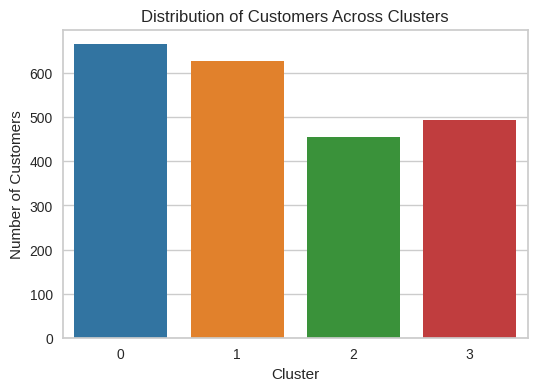

In [60]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='kmeans_cluster', data=df, palette='tab10')
plt.title("Distribution of Customers Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

The distribution is reasonably balanced with no dominant or near-empty cluster. Balanced cluster sizes indicate KMeans found genuine natural groupings rather than one large catch-all cluster with small satellite groups. This further validates the n=4 model choice.

#### Income vs Spending

In [61]:
df.groupby('kmeans_cluster')[['Income', 'total_spend']].mean()

,Income,total_spend
kmeans_cluster,,
0,10.926,6.375
1,11.194,7.044
2,10.561,4.068
3,10.133,4.224


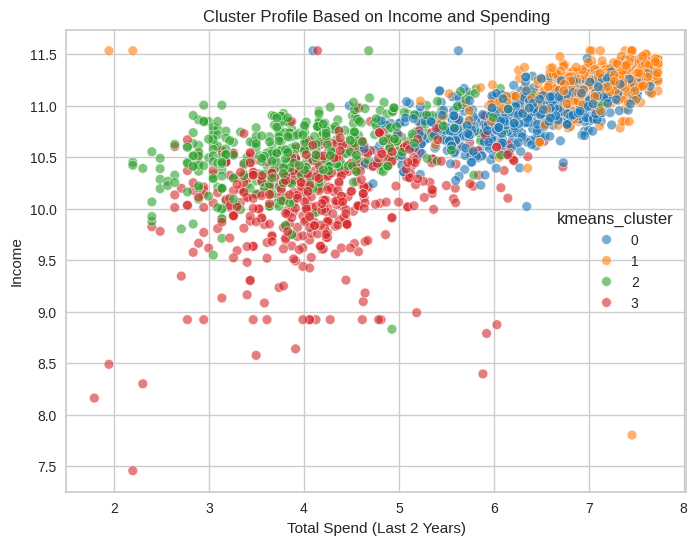

In [62]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='total_spend',
    y='Income',
    hue='kmeans_cluster',
    palette='tab10',
    alpha=0.6
)

plt.title("Cluster Profile Based on Income and Spending")
plt.xlabel("Total Spend (Last 2 Years)")
plt.ylabel("Income")
plt.show()

##### Observations:

The scatter plot reveals a clear positive correlation between income and total spend across all clusters, confirming that higher-earning customers tend to spend more. Cluster 1 occupies the top-right quadrant with both the highest income and highest spend, forming the most compact and well-separated group. Cluster 0 sits immediately below in spend, with high income but a wider horizontal spread indicating internal spend variability. Clusters 2 and 3 heavily overlap in the low-to-mid spend region (2.0–5.0) and can only be meaningfully separated by income level — Cluster 2 sits higher on the income axis while Cluster 3 extends down to the lowest income values (~7.4), confirming that spend alone is insufficient to distinguish the lower tier and that income and behavioural features together drive their separation.

- Cluster 0: Slightly Lower Income – High Spending (Affluent Spenders)
- Cluster 1: Highest Income – Highest Spending (Premium Customers)
- Cluster 2: Mid-High Income – Low-Mid Spending (Mid-Income Conservative)
- Cluster 3: Lowest + widest spread Income – Low-Mid Spending (Low-Income Dispersed)

#### Spending distribution per cluster

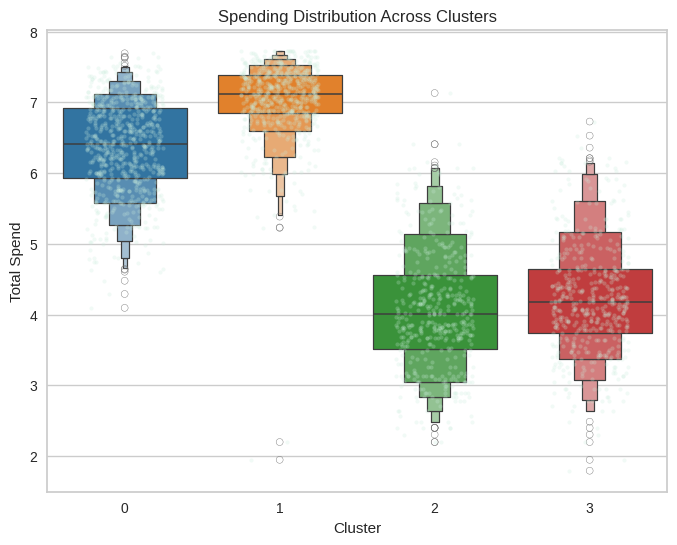

In [63]:
plt.figure(figsize=(8, 6))

sns.stripplot(
    x='kmeans_cluster',
    y='total_spend',
    data=df,
    color='#CBEDDD',
    alpha=0.25,
    jitter=0.25,
    size=3
)

sns.boxenplot(
    x='kmeans_cluster',
    y='total_spend',
    data=df,
    hue='kmeans_cluster',
    palette='tab10',
    legend=False
)

plt.title("Spending Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Total Spend")
plt.show()

##### Observations:

Two clear spend tiers are visible: Clusters 0 and 1 as high spenders (medians ~6.5 and ~7.1 respectively) and Clusters 2 and 3 as low-to-mid spenders (medians ~4.05 and ~4.2). Cluster 1 is the most consistent high spender with a tight IQR and minimal spread, while Cluster 0 shows wider variance with a lower tail approaching Cluster 2 levels, indicating a boundary sub-group within Cluster 0 that spends more conservatively. Clusters 2 and 3 are nearly statistically indistinguishable on spend alone — same median, similar IQR — making this dimension insufficient on its own to separate them, with their differentiation relying on income level, deal sensitivity, and behavioural signals captured in other features.

#### Income distribution per cluster

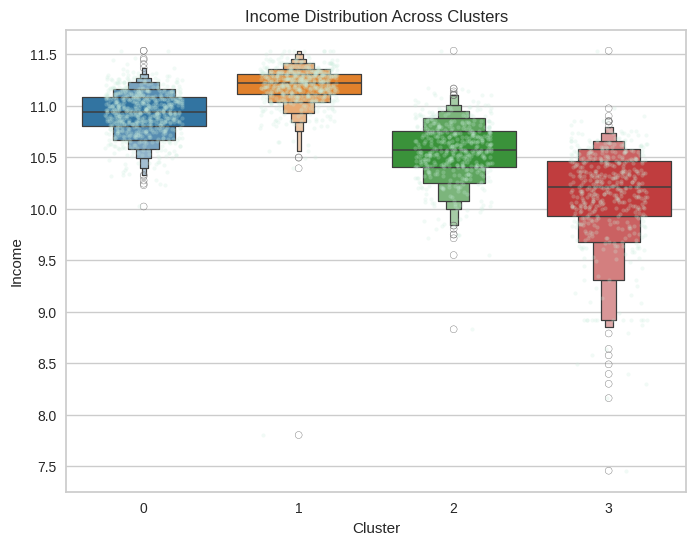

In [64]:
plt.figure(figsize=(8, 6))

sns.stripplot(
    x='kmeans_cluster',
    y='Income',
    data=df,
    color='#CBEDDD',
    alpha=0.25,
    jitter=0.25,
    size=3
)

sns.boxenplot(
    x='kmeans_cluster',
    y='Income',
    data=df,
    hue='kmeans_cluster',
    palette='tab10',
    legend=False
)

plt.title("Income Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Income")
plt.show()

##### Observations:

Income separates the four clusters in a clean descending order — Cluster 1 (median ~ 11.2) is the highest and most compact, confirming a financially stable and homogeneous premium group, followed by Cluster 0 (median ~ 11.0) with a similarly tight distribution. Cluster 2 sits at a mid-income level (median ~ 10.55) with moderate spread, while Cluster 3 has the lowest median (~ 10.2) and by far the widest dispersion — its lower tail extends to ~ 7.5, a floor no other cluster approaches — indicating that Cluster 3 contains genuinely low-income individuals alongside near-mid-income members, making it the most internally heterogeneous segment. 

#### Campaign acceptance analysis

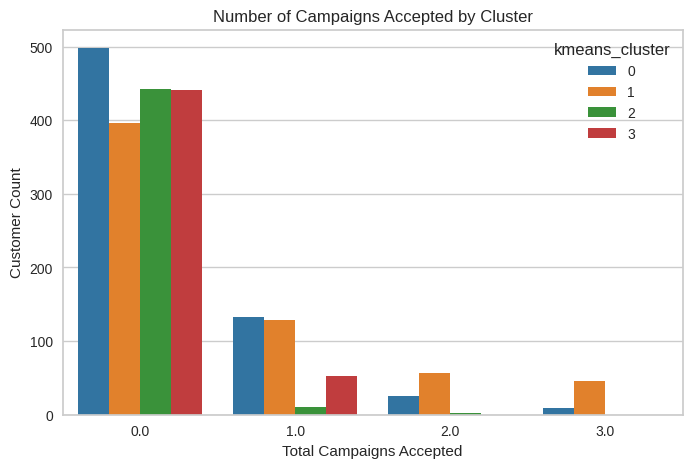

In [65]:
plt.figure(figsize=(8, 5))
sns.countplot(
    x='campaign_accept_count',
    hue='kmeans_cluster',
    data=df,
    palette='tab10'
)

plt.title("Number of Campaigns Accepted by Cluster")
plt.xlabel("Total Campaigns Accepted")
plt.ylabel("Customer Count")
plt.show()

##### Observations:

Campaign acceptance is low across all clusters, with zero-acceptors dominating every segment. Cluster 1 stands out as the most campaign-responsive — it has the smallest zero-bar (~ 400) relative to its size and is the only cluster sustaining meaningful engagement at 2 (~ 57) and 3 (~ 46) campaign acceptances, making it the only segment where multi-touch campaign investment is justified. Cluster 0 shows moderate single-campaign responsiveness (~ 135) but drops sharply beyond that. Cluster 3 has a small but visible 1-campaign bar (~ 52) with near-zero beyond it, indicating one-time activation potential only. Cluster 2 is essentially campaign-immune — barely ~ 10 customers accepted even one campaign — making it the segment where outbound campaign spend should be eliminated entirely.

#### Deal sensitivity

/tmp/ipykernel_55/2474453307.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




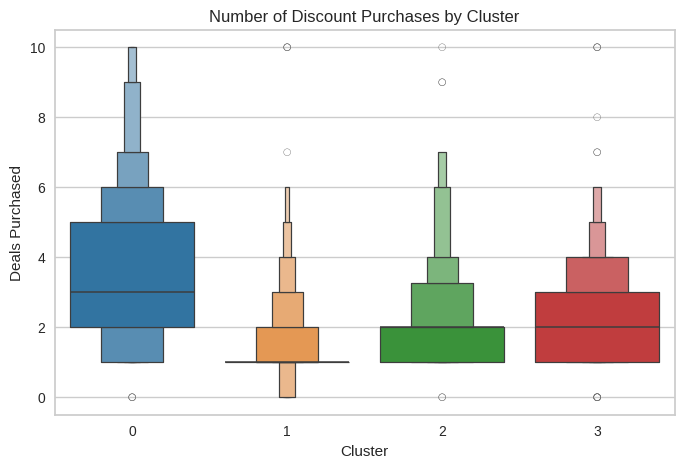

In [66]:
plt.figure(figsize=(8, 5))
sns.boxenplot(
    x='kmeans_cluster',
    y='NumDealsPurchases',
    data=df,
    palette='tab10'
)

plt.title("Number of Discount Purchases by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Deals Purchased")
plt.show()

##### Observations:

Cluster 0 is by far the most deal-engaged segment, with a median of ~ 3 and a wide IQR of 1–5 extending to a whisker of 9–10, confirming that deals meaningfully accelerate purchasing for this high-spend group. Clusters 2 and 3 show near-identical moderate deal engagement (median ~ 2, IQR 1–3 to 3.3), making discounts relevant but not the defining behaviour for either. Cluster 1 has the lowest deal engagement of all — median ~ 1, tight IQR, and lower fence at 1 — consistent with a price-insensitive premium profile where discounting is unnecessary and risks undermining perceived brand value.

#### Product-wise spending

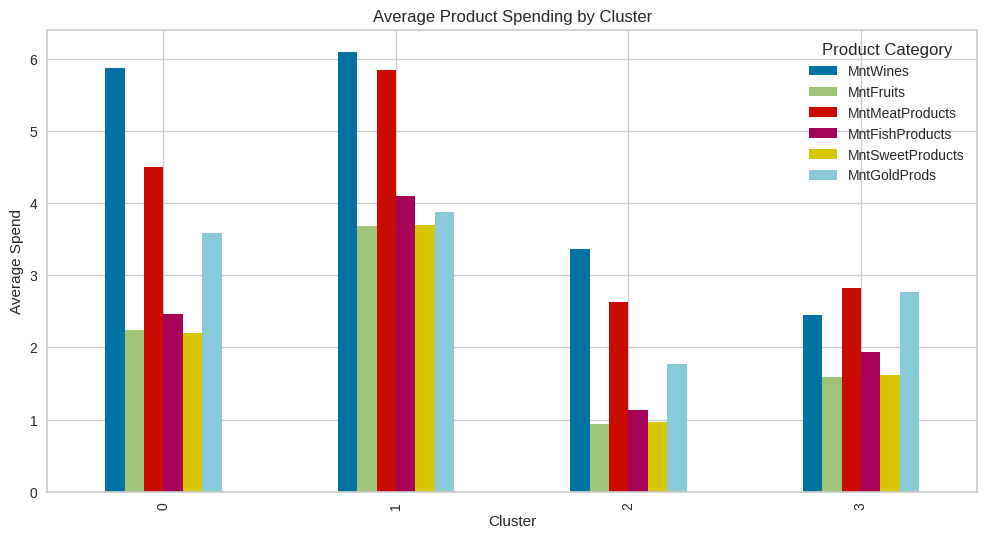

In [67]:
product_means = (
    df.groupby('kmeans_cluster')[spend_cols]
      .mean()
)

product_means.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Average Product Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spend")
plt.legend(title="Product Category")
plt.show()

##### Observations:

Cluster 1 leads across all six product categories with Wines (~ 6.1) and Meat (~ 5.9) nearly equal, and meaningful spend across Fruits, Fish, Sweets, and Gold (~ 3.7–4.1) — the only cluster with genuine cross-category breadth, reflecting a balanced premium consumption profile. Cluster 0 is strongly wine-dominant (~ 5.9) with solid Meat (~ 4.5) and notably elevated Gold (~ 3.6), suggesting a wine-and-meat household buyer with gifting tendencies. Cluster 2 shows wine as the sole meaningful category (~ 3.35) with all others near the floor, while Cluster 3 presents the most distinctive pattern — Gold (~ 2.8) nearly matches Meat (~ 2.83) as the top categories despite overall low spend, the highest gold prominence relative to total spend of any cluster, strongly signalling occasion-driven gifting behaviour as the primary purchase motivation for this segment.

## 12. Cluster Profiling <a id='cluster-profiling'></a>

In [68]:
cluster_profile = (
    df.groupby('kmeans_cluster')[cluster_features]
      .mean()
      .sort_values('total_spend', ascending=False)
)

cluster_profile.to_csv("outputs/kmeans_cluster_profiles.csv")
cluster_profile

,Income,Age,Customer_For,num_children,total_spend,total_purchases,spend_to_income_ratio,MntWines_ratio,MntMeatProducts_ratio,MntGoldProds_ratio,web_purchase_ratio,store_purchase_ratio,catalog_purchase_ratio,NumWebVisitsMonth,deal_purchase_ratio,campaign_accept_count,Recency
kmeans_cluster,,,,,,,,,,,,,,,,,
1,11.194,57.987,330.035,0.246,7.044,18.996,0.018,0.425,0.328,0.065,0.250,0.443,0.304,2.638,0.073,0.604,49.534
0,10.926,60.814,423.641,1.174,6.375,16.177,0.012,0.635,0.176,0.087,0.399,0.432,0.168,6.220,0.238,0.316,48.317
3,10.133,49.475,381.424,0.966,4.224,5.744,0.004,0.204,0.256,0.249,0.369,0.537,0.086,7.034,0.353,0.105,49.777
2,10.561,58.796,253.270,1.578,4.068,5.596,0.002,0.523,0.242,0.105,0.292,0.657,0.051,5.655,0.355,0.033,48.921


## 13. Final Customer Segmentation and Profiling <a id='final-customer-segmentation'></a>

Based on spending behavior, income distribution, campaign engagement, discount responsiveness, and product-level preferences, four distinct and actionable customer segments emerge. Each cluster represents a unique customer persona with clear business implications.

---

### 🔵 Cluster 0 — "Deal-Influenced High Spenders"
Size: ~660 customers (29%)

- Income: Upper-mid to high (mean log 10.926), second highest across clusters with a reasonably tight distribution — financially capable customers with consistent earning levels
- Spending: Second highest total spend (mean log 6.375) with the widest IQR among high-spend clusters — a core of strong spenders with a lower-spending boundary sub-group
- Deal sensitivity: Highest deal purchase ratio (0.238) and highest absolute deal count (median 3, IQR 1–5) — deals meaningfully accelerate purchases for this group, though they are deal-influenced rather than deal-dependent
- Campaign responsiveness: Moderate — ~135 customers accepted one campaign, but very few engaged with 2+; single-touch campaigns can work but sustained multi-campaign investment has limited ROI here
- Product affinity: Wine-dominant (~59% of spend) with strong Meat and notably elevated Gold — a wine-and-meat household profile with gifting tendencies
- Channel behaviour: Balanced store and web usage with moderate catalog engagement


#### Business label: 
High-value opportunistic buyers who respond to well-timed promotions
#### Strategic recommendation: 
Structured deal calendars (monthly wine promotions, meat bundle offers) to drive volume without ad-hoc discounting. Gold product gifting campaigns around seasonal occasions. Single-touch campaigns with deal-led creative. Loyalty tier recognition to reward tenure without pure margin sacrifice. Avoid over-discounting — their spend capacity is genuine and margins should be protected.

---

### 🟠 Cluster 1 — "Premium Elite"
Size: ~628 customers (28%)

- Income: Highest of all clusters (mean log 11.194), tight distribution with minimal variance — the most financially stable and homogeneous segment
- Spending: Highest total spend (mean log 7.044) with a compact, consistent distribution — high spend is the norm here, not driven by outliers
- Deal sensitivity: Lowest deal purchase ratio and lowest absolute deal count (median ~1) — price is not a purchase driver; these customers buy on preference and quality
- Campaign responsiveness: Highest of all clusters — only segment with sustained 2 and 3 campaign acceptance (~60 and ~50 customers); well-constructed campaigns directly influence purchase behaviour
- Product affinity: Balanced across all six categories with Wines (~ 6.1) and Meat (~ 5.9) leading equally — the only cluster spending meaningfully on Fruits, Fish, Sweets, and Gold simultaneously, reflecting genuine premium and diverse consumption
- Channel behaviour: Moderate web visits (low browsing = high intent), strongest catalog engagement of all clusters, solid in-store presence — decisive buyers who do not need to research extensively

#### Business label: 
Financially stable, brand-loyal premium customers with diversified consumption and high campaign receptivity

#### Strategic recommendation: 
Invest in personalised, high-quality campaigns — this is the only segment with demonstrated multi-campaign ROI. Develop VIP or concierge tiers: exclusive product launches, sommelier-led wine selections, premium gift options. Leverage catalog as a primary channel with editorial content. Never discount — use value-adds (complimentary items, early access) instead. Monitor for churn signals closely; any inactivity should trigger immediate personalised outreach given the high LTV at stake.

---

### 🟢 Cluster 2 — "Mid-Income Conservatives"
Size: ~458 customers (20%)

- Income: Mid-range (mean log 10.561), moderate spread with a lower tail to ~9.5 — a genuine middle-income group with some financially constrained members
- Spending: Lowest total spend (mean log 4.068), near-identical to Cluster 3 in central tendency but slightly tighter distribution — conservative and consistent in spending behaviour
- Deal sensitivity: Moderate deal engagement (median ~2, deal ratio ~0.353) — deals attract purchases but are not the defining behaviour; self-directed deal discovery rather than campaign-driven
- Campaign responsiveness: Near-zero — barely ~10 customers accepted any campaign, making this the most campaign-resistant segment in the dataset; outbound campaign spend here is essentially wasted
- Product affinity: Wine is the only meaningful category (~3.35), with all others near the floor — the most category-sparse cluster, indicating conservative and habitual purchasing confined to a single staple
- Channel behaviour: Highest web visit frequency — active digital browsers who research extensively before committing; store purchase ratio is moderate

#### Business label: 
Cautious, wine-focused mid-income customers who browse digitally but convert infrequently
#### Strategic recommendation: 
Low-cost digital engagement: email newsletters, website personalisation, retargeting ads. Do not invest in outbound campaigns. Wine-focused content and value messaging will resonate most. Entry-level loyalty mechanic (digital stamp card, web purchase points) to build repeat habit without requiring high spend thresholds. Explore sub-segmentation — the income dispersion within this cluster suggests a financially constrained sub-group and a near-mid sub-group who may respond to different activation strategies.

---

### 🔴 Cluster 3 — "Low-Income Gold Seekers"
Size: ~496 customers (22%)

- Income: Lowest of all clusters (mean log 10.133) with the widest income dispersion — lower whisker to ~8.8 and outliers to ~7.5, containing genuinely low-income individuals alongside near-mid-income customers in the same segment
- Spending: Third in total spend (mean log 4.224), marginally above Cluster 2 but with wider variance — some members punch above their income level on spending, a potential financial stress signal
- Deal sensitivity: Moderate (deal ratio ~0.355, median ~2) — comparable to Cluster 2, suggesting deals play a similar role in both lower-tier clusters
- Campaign responsiveness: Low but not negligible — ~57 customers accepted one campaign, dropping to near-zero at 2+; single-touch, deal-led campaign creative may work selectively
- Product affinity: Gold Products (~ 2.8) nearly matches Meat (~ 2.83) as the top spending category — the highest gold prominence relative to total spend of any cluster, strongly indicating occasion-driven or gifting purchasing behaviour; Wine (~ 2.5) is present but secondary
- Channel behaviour: Moderate web visits and store usage; lower catalog engagement than high-spend clusters
#### Business label: 
Budget-constrained, gold-and-gifting-oriented customers with opportunistic purchasing behaviour
#### Strategic recommendation: 
Seasonal gifting campaigns centred on Gold Products — Christmas, Valentine's Day, Mother's Day — represent the clearest activation opportunity for this segment. Low-cost single-touch campaigns with deal-led creative may generate occasional uplift. Flag the financially stressed sub-group (income outliers below 9.5) for passive retention rather than active acquisition spend. Do not invest in catalog or premium product campaigns — the income floor makes premium conversion unlikely. Monitor for instances of spend exceeding income level, which may indicate payment risk or churn vulnerability.

## 14 Investment Prioritisation <a id='investment-prioritisation'></a>



Based on revenue potential, campaign ROI, and strategic fit, the following prioritisation is recommended for marketing budget allocation:

| Priority | Cluster | Segment Name | Revenue Potential | Rationale |
|---|---|---|---|---|
| 🥇 1st | Cluster 1 | **Premium Elite** | ⭐ Highest | Highest income and spend; only segment with multi-campaign ROI (0.619 avg. acceptances); price-insensitive with balanced cross-category consumption; losing one customer here has outsized LTV impact |
| 🥈 2nd | Cluster 0 | **Deal-Influenced High Spenders** | 🔼 High | Second highest income and spend; deal-accelerated purchasing creates strong volume potential; structured promotional calendars can drive revenue without margin erosion; largest segment by size (29%) amplifies impact |
| 🥉 3rd | Cluster 3 | **Low-Income Gold Seekers** | 🔷 Medium | Lowest income but distinctive gold product affinity signals a real gifting occasion opportunity; single-touch deal-led campaigns show marginal responsiveness; high income dispersion means careful sub-targeting is needed to avoid wasted spend |
| 4th | Cluster 2 | **Mid-Income Conservatives** | 🔽 Low | Near-zero campaign acceptance makes outbound spend unjustifiable; wine-only product engagement limits upsell opportunity; highest web visit frequency offers a low-cost digital engagement channel as the sole viable activation path |

> **Note:** Prioritisation is based on the final KMeans model (k=4, PCA n=4 components, silhouette=0.268). 

## 15. Strategic Recommendations Matrix <a id='strategic-recommendations'></a>



The following matrix summarises actionable strategies per segment across six business dimensions:

| Strategy Area | 🔵 Cluster 0<br>**Deal-Influenced High Spenders** | 🟠 Cluster 1<br>**Premium Elite** | 🟢 Cluster 2<br>**Mid-Income Conservatives** | 🔴 Cluster 3<br>**Low-Income Gold Seekers** |
|---|---|---|---|---|
| **Pricing** | Structured deal calendars; monthly wine & meat promotions with margin guardrails | Premium & exclusive pricing; no discounting; value-adds over price cuts | Passive deal discovery; flash sales on wine; entry-level value packs | Seasonal gifting deals on Gold Products; minimum basket thresholds to protect margins |
| **Channel** | In-store promotions + web retargeting; deal-led creative on both channels | Catalog & personalised direct outreach; in-store premium experience | Digital-first; website personalisation, email drip, low-cost retargeting | Low-cost digital; single-touch email campaigns around seasonal occasions |
| **Product Focus** | Wine & Meat bundles; Gold gifting promotions around occasions | Premium Wines, Meat & full cross-category range; specialty and new product launches | Wine-focused content and offers; no upsell beyond core category | Gold Products as primary lever; Meat as secondary; avoid premium category pushes |
| **Campaign** | Single-touch deal-led campaigns; avoid multi-campaign investment | High-value personalised multi-campaign strategy; VIP events; exclusive previews | Eliminate outbound campaigns entirely; passive digital content only | Single-touch seasonal campaigns; deal-led creative; urgency and occasion messaging |
| **Retention** | Loyalty programme rewarding wine & meat staple purchases; tier recognition for tenure | Concierge-level CRM; exclusive access; personalised product recommendations | Entry-level digital loyalty mechanic; web purchase points; deal discovery content | Occasion-based re-engagement; Gold gifting reminders ahead of seasonal peaks |
| **Risk** | Margin erosion if deal cadence becomes ad-hoc; avoid training deal dependency | Churn if experience feels generic or undifferentiated; never discount | Near-zero conversion on outbound spend; high browse-to-buy gap | Income constraints cap revenue ceiling; over-promotion without basket thresholds destroys margins |



## 16. Analytical Notes & Caveats <a id='analytical-notes'></a>

---

### Model Choices

- KMeans (k=4) was selected based on Elbow Method and Silhouette Score validation across multiple k values. The final k=4 configuration produces well-separated, business-interpretable clusters with a silhouette score of 0.268.
- Three PCA configurations were systematically evaluated (n=4, n=6, n=9). Silhouette score decreased monotonically as components increased (0.268 → 0.203 → 0.191), confirming that higher variance retention was adding noise rather than signal. PCA with n=4 components was selected as the optimal configuration, retaining 60.7% of variance while achieving the highest cluster separation.
- PCA-based clustering (silhouette: 0.268) outperformed raw feature clustering (silhouette: 0.164) by 63%, confirming that dimensionality reduction materially improved cluster quality and was not merely a preprocessing formality.
- Cluster stability was validated across four random seeds (0, 21, 42, 100) with silhouette variance of less than 0.0003, confirming the four segments represent genuine data structure rather than random initialisation artefacts.
- Cluster profiling was performed on original feature values (not PCA components) to preserve business interpretability. All means referenced in this report are in original or log-transformed scale as labelled.
- Feature scaling (StandardScaler) was applied before PCA and clustering. Income and total spend values are log-scaled for clustering stability; business stakeholders should reference back-transformed values for decision-making.

---

### Data Quality Flags

- 24 records had missing Income values — imputed using the dataset median. This is appropriate given the right-skewed income distribution and the small proportion of affected records (< 1.1%).
- One or more customers have implausibly high Age values (e.g., 133 years), likely caused by data entry errors in the `Year_Birth` field (e.g., 1893 entered instead of 1993). These were capped via force-fitting at the 99.5th percentile but should be reviewed for data quality remediation at source before any future model refresh.
- Recency is uniformly distributed across all four clusters (~48–50 days average), indicating no cluster is disproportionately at churn risk based on recency alone. Recency should not be used as a standalone churn signal for this dataset.
- Cluster 3 contains a sub-group of customers with income values as low as ~7.5 (log-scale), significantly below the cluster median. These extreme low-income observations may represent financially stressed customers and warrant separate monitoring for payment risk or early churn.
- One anomalous low-income outlier (~7.8 log-scale) exists within Cluster 1, which is otherwise the most financially homogeneous segment. This observation is inconsistent with the cluster profile and is likely a data quality issue rather than a true Premium Elite member.

---

### Limitations

- Cluster labels are derived from a single dataset snapshot. Customer behaviour evolves with macroeconomic conditions, seasonal patterns, and lifecycle changes — segment membership should be re-evaluated at minimum quarterly and the model retrained on fresh data every 6–12 months.
- The monotonic decline in silhouette score as PCA components increase suggests that customer differentiation in this dataset is concentrated in a low-dimensional signal space, likely dominated by the income-spend axis. This limits the model's ability to capture subtle multi-dimensional behavioural differences and may result in soft boundaries between adjacent clusters (particularly Clusters 2 and 3).
- Clusters 2 and 3 are nearly indistinguishable on spend level alone (means of 4.068 vs 4.224). Their separation relies on income level, product affinity, and deal sensitivity — features that may shift over time, potentially causing members to migrate between these two segments.
- KMeans assumes spherical, equally-sized clusters and is sensitive to feature scale. While StandardScaler and PCA mitigate these limitations, the assumption of cluster sphericity may not perfectly reflect the true shape of customer segments in this data.
- The segmentation is descriptive, not predictive. Cluster membership does not imply causality — for example, Cluster 1's campaign responsiveness does not guarantee that campaigns caused their high spend, only that the two are correlated within this dataset.